# Test-Time Optimization — Interactive Test

Test notebook for `src/models/test_time_opt.py` (Week 3, Task 2)

**Checklist:**
1. Import & Setup
2. Basic `optimize_fusion_weights()` call
3. Loss curve visualization
4. Inference timing benchmark
5. Grid search table
6. Weight comparison (initial vs optimized)
7. Early stopping behavior

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from src.models.test_time_opt import (
    optimize_fusion_weights,
    grid_search_hyperparams,
)

print("Imports OK")

Imports OK


## 1. Setup — Simulated CLIP Embeddings

In [2]:
# Setup Real BigEarthNet-S2 Data & CLIP
import clip
from torch.utils.data import DataLoader
from src.datasets.bigearth_loader import BigEarthNetDataset
from src.models.per_band_encoder import encode_multispectral_bands
from src.models.fiedler import compute_fiedler_magnitude_weights
from src.models.affinity_graph import compute_affinity_graph

print("Loading CLIP model...")
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
model, _ = clip.load("ViT-B/16", device=device)

# Load 1 patch
ds = BigEarthNetDataset(root=os.path.join(PROJECT_ROOT, "data/BigEarthNetS2"), split="all", max_samples=1, use_cache=False)
if len(ds) == 0:
    raise ValueError("No patches found in BigEarthNet-S2 dataset!")
loader = DataLoader(ds, batch_size=1)
batch = next(iter(loader))

image_bands = batch["image"][0] # (12, 120, 120)
query_text = "A satellite image of complex cultivation patterns"

# Encode
print(f"Encoding 12 bands and query: '{query_text}' ...")
band_embeddings = encode_multispectral_bands(image_bands, model, device).clone() # (12, 512)
query_tokens = clip.tokenize([query_text]).to(device)
with torch.no_grad():
    query_embedding = model.encode_text(query_tokens).squeeze(0).float() # (512,)

# Move back to CPU for optimization as in the original test script
band_embeddings = band_embeddings.cpu().clone()
query_embedding = query_embedding.cpu().clone()

print("Computing initial Fiedler weights...")
affinity_matrix = compute_affinity_graph(band_embeddings, query_embedding, sigma=0.5)
w_init = compute_fiedler_magnitude_weights(affinity_matrix)

print(f"Band embeddings : {tuple(band_embeddings.shape)}")
print(f"Query embedding : {tuple(query_embedding.shape)}")
print(f"Initial weights : {[round(w, 4) for w in w_init.tolist()]}")
print(f"Weights sum     : {w_init.sum().item():.4f}")


Loading CLIP model...
Encoding 12 bands and query: 'A satellite image of complex cultivation patterns' ...
Computing initial Fiedler weights...
Band embeddings : (12, 512)
Query embedding : (512,)
Initial weights : [0.2791, 0.0539, 0.0477, 0.0915, 0.0257, 0.0535, 0.0375, 0.1214, 0.0418, 0.2292, 0.0054, 0.0134]
Weights sum     : 1.0000


## 2. Basic Optimization

In [3]:
result = optimize_fusion_weights(
    band_embeddings=band_embeddings,
    query_embedding=query_embedding,
    w_init=w_init,
    num_steps=5,
    lr=0.01,
    lambda_m=0.1,
    k=5,
)

print(f"Steps run       : {result.num_steps_run}")
print(f"Elapsed         : {result.elapsed_ms:.2f} ms")
print(f"Weights sum     : {result.optimized_weights.sum().item():.6f}")
print(f"Fused L2 norm   : {torch.norm(result.fused_embedding).item():.6f}")
print(f"Loss history    : {[f'{l:.6f}' for l in result.loss_history]}")

Steps run       : 5
Elapsed         : 8.13 ms
Weights sum     : 1.000000
Fused L2 norm   : 1.000000
Loss history    : ['0.032728', '0.032505', '0.032283', '0.032062', '0.031842']


## 3. Loss Curve — More Steps

In [4]:
result_50 = optimize_fusion_weights(
    band_embeddings=band_embeddings,
    query_embedding=query_embedding,
    w_init=w_init,
    num_steps=50,
    lr=0.05,
    lambda_m=0.1,
    k=5,
    early_stop_tol=0.0,  # disable early stopping for full curve
)

losses = result_50.loss_history
print(f"Step  0: {losses[0]:.6f}")
print(f"Step 24: {losses[24]:.6f}")
print(f"Step 49: {losses[49]:.6f}")
print(f"Decrease: {(1 - losses[-1]/losses[0])*100:.2f}%")

Step  0: 0.032728
Step 24: 0.020769
Step 49: 0.018250
Decrease: 44.24%


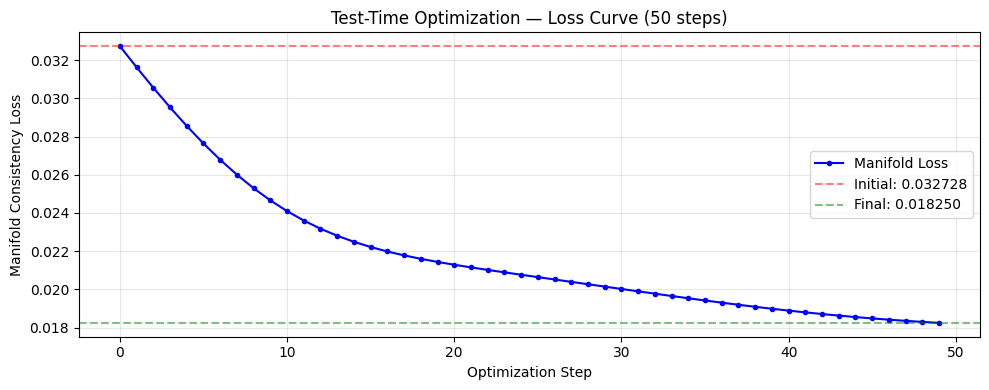

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(losses)), losses, 'b-o', markersize=3, linewidth=1.5, label='Manifold Loss')
ax.axhline(y=losses[0], color='r', linestyle='--', alpha=0.5, label=f'Initial: {losses[0]:.6f}')
ax.axhline(y=losses[-1], color='g', linestyle='--', alpha=0.5, label=f'Final: {losses[-1]:.6f}')
ax.set_xlabel('Optimization Step')
ax.set_ylabel('Manifold Consistency Loss')
ax.set_title('Test-Time Optimization — Loss Curve (50 steps)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Inference Timing Benchmark

In [6]:
# Warm-up
for _ in range(5):
    optimize_fusion_weights(
        band_embeddings=band_embeddings,
        query_embedding=query_embedding,
        w_init=w_init, num_steps=5, lr=0.01,
    )

# Benchmark: 3 configs × 20 runs
configs = [(3, 0.01), (5, 0.01), (7, 0.02)]
num_runs = 20

print(f"{'config':>15s}  {'avg_ms':>8s}  {'min_ms':>8s}  {'max_ms':>8s}  {'< 200ms':>8s}")
print("-" * 55)
for ns, lr_val in configs:
    times = []
    for _ in range(num_runs):
        res = optimize_fusion_weights(
            band_embeddings=band_embeddings,
            query_embedding=query_embedding,
            w_init=w_init, num_steps=ns, lr=lr_val,
        )
        times.append(res.elapsed_ms)
    avg = sum(times)/len(times)
    mn, mx = min(times), max(times)
    ok = 'YES' if avg < 200 else 'NO'
    print(f"  steps={ns},lr={lr_val}  {avg:>7.2f}  {mn:>7.2f}  {mx:>7.2f}  {ok:>8s}")

         config    avg_ms    min_ms    max_ms   < 200ms
-------------------------------------------------------
  steps=3,lr=0.01     1.52     1.12     2.29       YES
  steps=5,lr=0.01     1.90     1.64     2.50       YES
  steps=7,lr=0.02     3.55     2.03     6.95       YES


## 5. Grid Search

In [7]:
grid_results = grid_search_hyperparams(
    band_embeddings=band_embeddings,
    query_embedding=query_embedding,
    w_init=w_init,
    num_steps_choices=(3, 5, 7),
    lr_choices=(0.005, 0.01, 0.02),
    lambda_m=0.1,
    k=5,
)

print(f"{'rank':>4s}  {'steps':>5s}  {'lr':>6s}  {'loss':>10s}  {'decrease%':>10s}  {'time_ms':>8s}")
print("-" * 52)
for i, entry in enumerate(grid_results):
    marker = ' <-- BEST' if i == 0 else ''
    print(f"{i+1:>4d}  {entry.num_steps:>5d}  {entry.lr:>6.3f}  "
          f"{entry.final_loss:>10.6f}  {entry.loss_decrease_pct:>9.2f}%  "
          f"{entry.elapsed_ms:>7.2f}{marker}")

rank  steps      lr        loss   decrease%   time_ms
----------------------------------------------------
   1      7   0.020    0.030140       7.91%     3.36 <-- BEST
   2      5   0.020    0.030978       5.35%     2.28
   3      7   0.010    0.031407       4.03%     2.37
   4      3   0.020    0.031842       2.71%     1.19
   5      5   0.010    0.031842       2.71%     1.70
   6      7   0.005    0.032062       2.03%     3.02
   7      3   0.010    0.032283       1.36%     1.79
   8      5   0.005    0.032283       1.36%     1.65
   9      3   0.005    0.032505       0.68%     2.68


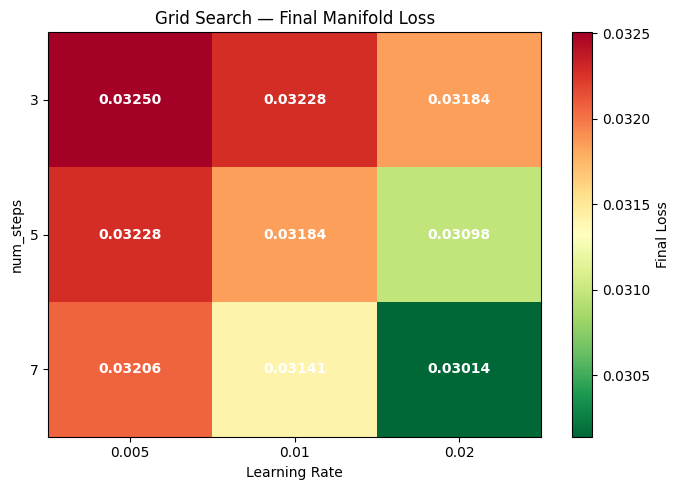

In [8]:
# Visualize grid as heatmap
import itertools

steps_list = [3, 5, 7]
lr_list = [0.005, 0.01, 0.02]

loss_grid = np.zeros((len(steps_list), len(lr_list)))
for entry in grid_results:
    i = steps_list.index(entry.num_steps)
    j = lr_list.index(entry.lr)
    loss_grid[i, j] = entry.final_loss

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(loss_grid, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(lr_list)))
ax.set_xticklabels([f'{lr}' for lr in lr_list])
ax.set_yticks(range(len(steps_list)))
ax.set_yticklabels([f'{s}' for s in steps_list])
ax.set_xlabel('Learning Rate')
ax.set_ylabel('num_steps')
ax.set_title('Grid Search — Final Manifold Loss')

# Annotate cells
for i, j in itertools.product(range(len(steps_list)), range(len(lr_list))):
    ax.text(j, i, f'{loss_grid[i,j]:.5f}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

plt.colorbar(im, label='Final Loss')
plt.tight_layout()
plt.show()

## 6. Weight Comparison (Initial vs Optimized)

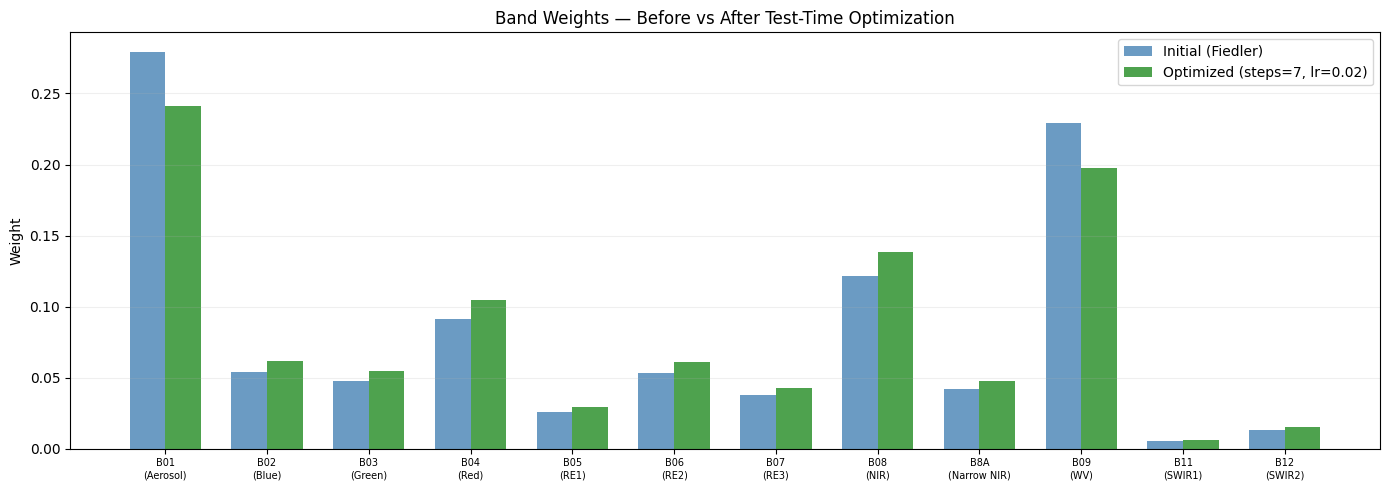


Weight changes (optimized - initial):
  B01 (Aerosol): 0.2791 -> 0.2409  (down -0.0382)
    B02 (Blue): 0.0539 -> 0.0615  (up +0.0076)
   B03 (Green): 0.0477 -> 0.0544  (up +0.0067)
     B04 (Red): 0.0915 -> 0.1044  (up +0.0129)
     B05 (RE1): 0.0257 -> 0.0294  (up +0.0036)
     B06 (RE2): 0.0535 -> 0.0610  (up +0.0076)
     B07 (RE3): 0.0375 -> 0.0428  (up +0.0053)
     B08 (NIR): 0.1214 -> 0.1385  (up +0.0172)
  B8A (Narrow NIR): 0.0418 -> 0.0477  (up +0.0059)
      B09 (WV): 0.2292 -> 0.1978  (down -0.0314)
   B11 (SWIR1): 0.0054 -> 0.0061  (~ +0.0008)
   B12 (SWIR2): 0.0134 -> 0.0153  (up +0.0019)


In [9]:
best = grid_results[0]
best_w = best.optimized_weights.numpy()
init_w = w_init.numpy()

BAND_LABELS = ["B01\n(Aerosol)", "B02\n(Blue)", "B03\n(Green)", "B04\n(Red)",
               "B05\n(RE1)", "B06\n(RE2)", "B07\n(RE3)", "B08\n(NIR)",
               "B8A\n(Narrow NIR)", "B09\n(WV)", "B11\n(SWIR1)", "B12\n(SWIR2)"]

B = len(init_w)
if len(BAND_LABELS) < B:
    BAND_LABELS = BAND_LABELS + [f"Band {i+1}" for i in range(len(BAND_LABELS), B)]

x = np.arange(B)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - width/2, init_w, width, label='Initial (Fiedler)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, best_w, width, label=f'Optimized (steps={best.num_steps}, lr={best.lr})',
               color='forestgreen', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(BAND_LABELS[:B], fontsize=7)
ax.set_ylabel('Weight')
ax.set_title('Band Weights — Before vs After Test-Time Optimization')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

# Print delta
print("\nWeight changes (optimized - initial):")
for i in range(B):
    delta = best_w[i] - init_w[i]
    arrow = "up" if delta > 0.001 else "down" if delta < -0.001 else "~"
    print(f"  {BAND_LABELS[i].replace(chr(10),' '):>12s}: {init_w[i]:.4f} -> {best_w[i]:.4f}  ({arrow} {delta:+.4f})")

## 7. Early Stopping Behavior

Requested: 200 steps
Actually ran: 200 steps
Final loss: 0.01899688
Time: 96.19 ms


/var/folders/_1/7696dy392rg6tzv9gs188d100000gn/T/ipykernel_46200/933488050.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


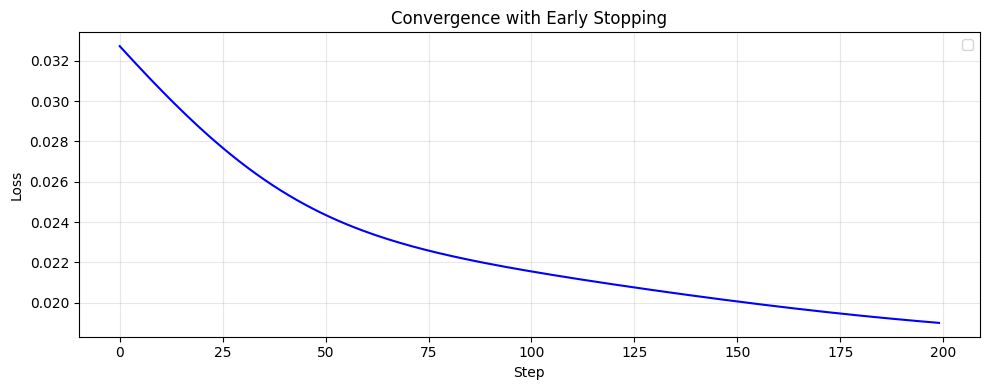

In [10]:
result_early = optimize_fusion_weights(
    band_embeddings=band_embeddings,
    query_embedding=query_embedding,
    w_init=w_init,
    num_steps=200,
    lr=0.01,
    lambda_m=0.1,
    k=5,
    early_stop_tol=1e-6,
)

print(f"Requested: 200 steps")
print(f"Actually ran: {result_early.num_steps_run} steps")
print(f"Final loss: {result_early.loss_history[-1]:.8f}")
print(f"Time: {result_early.elapsed_ms:.2f} ms")

if result_early.num_steps_run < 200:
    print(f"\nEarly stopping saved {200 - result_early.num_steps_run} steps!")

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 4))
losses_e = result_early.loss_history
ax.plot(range(len(losses_e)), losses_e, 'b-', linewidth=1.5)
if result_early.num_steps_run < 200:
    ax.axvline(x=result_early.num_steps_run - 1, color='r', linestyle='--',
               label=f'Early stop at step {result_early.num_steps_run}')
ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Convergence with Early Stopping')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()